In [ ]:
'''Predictive Maintenance of Industrial Machinery
AICTE 2026 — IBM SkillsBuild for University Engagements — Problem Statement No. 39
Goal: Predict the type of machine failure (Tool Wear, Heat Dissipation, Power Failure, Overstrain, Random, or No Failure) using sensor data — enabling proactive, data-driven maintenance.

Dataset: AI4I 2020 Predictive Maintenance Dataset (Kaggle, 10,000 records)
Platform: IBM Cloud Lite + watsonx.ai Studio (Jupyter Notebook, Python 3.11)
Algorithm: Random Forest Classifier + SMOTE rebalancing

Notebook Structure
#	Section
1	Import Libraries
2	Load Data (IBM Cloud Object Storage)
3	Exploratory Data Analysis (EDA)
4	Data Cleaning & Preprocessing
5	Train-Test Split
6	Baseline Model — Random Forest
7	Baseline Evaluation
8	Feature Importance
9	SMOTE Rebalancing
10	SMOTE Model Training & Evaluation
11	Cross Validation
12	Hyperparameter Tuning (GridSearchCV)
13	Save Best Model
14	Sample Prediction
15	Conclusion'''

In [ ]:
1. Import Libraries
All required libraries imported once at the top — avoids duplicate imports across cells.


In [2]:
# Core data & visualisation
import os, types
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Install ibm-cos-sdk (includes ibm_boto3) and boto3 (includes botocore) if not already installed
!pip install ibm-cos-sdk boto3 --quiet

# IBM Cloud Object Storage
from botocore.client import Config
import ibm_boto3

# Preprocessing & model selection
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

# Model persistence
import joblib

sns.set_style('whitegrid')
%matplotlib inline
print('All libraries imported successfully.')

All libraries imported successfully.


In [ ]:
2. Load Data — IBM Cloud Object Storage
Data is stored in IBM Cloud Object Storage and accessed via ibm_boto3.
The credentials below were auto-generated by watsonx.ai Studio's Insert to code feature.

In [3]:
# NOTE FOR EVALUATOR: This cell loads the dataset from IBM Cloud Object Storage.
# The credentials below are specific to the author's IBM Cloud Lite account (au-syd region).
# To run this notebook on your own IBM Cloud account, replace the credentials with your own.
# Dataset source: https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification

def __iter__(self): return 0
# IBM Cloud Object Storage credentials — auto-generated by watsonx.ai Studio
cos_client = ibm_boto3.client(
    service_name='s3',
    ibm_api_key_id='6GD9fQGVfwNKELr-Gwkn7ZizBSGJa70dNuXnJzkxMYy1',
    ibm_auth_endpoint='https://iam.cloud.ibm.com/identity/token',
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.au-syd.cloud-object-storage.appdomain.cloud'
)

bucket     = 'predictivemaintenanceml-donotdelete-pr-89tnolhibjsnfh'
object_key = 'predictive_maintenance.csv'

body = cos_client.get_object(Bucket=bucket, Key=object_key)['Body']
if not hasattr(body, '__iter__'):
    body.__iter__ = types.MethodType(__iter__, body)

df = pd.read_csv(body)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 10,000 rows × 10 columns


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
3. Exploratory Data Analysis (EDA)
We inspect the dataset structure, check for data quality issues, and visualise distributions before any modelling.

In [7]:
# 3.1  Basic structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [8]:
# 3.2  Summary statistics
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [9]:
# 3.3  Data quality — missing values and duplicates
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Duplicate rows: 0


Failure Type distribution:
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


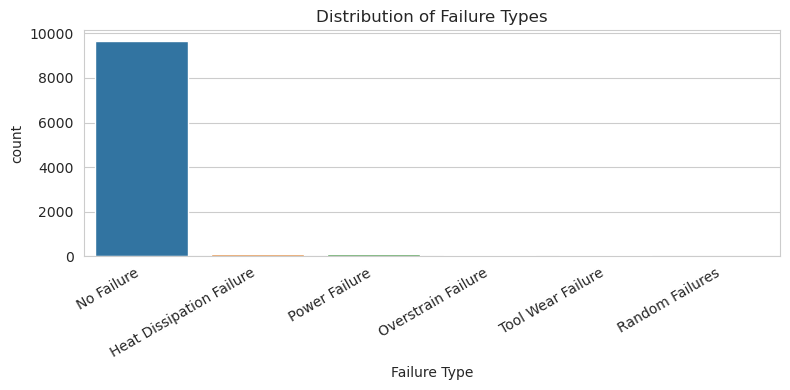

In [10]:
# 3.4  Target class distribution — reveals the class imbalance
print('Failure Type distribution:')
print(df['Failure Type'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(
    data=df, x='Failure Type',
    order=df['Failure Type'].value_counts().index
)
plt.xticks(rotation=30, ha='right')
plt.title('Distribution of Failure Types')
plt.tight_layout()
plt.show()

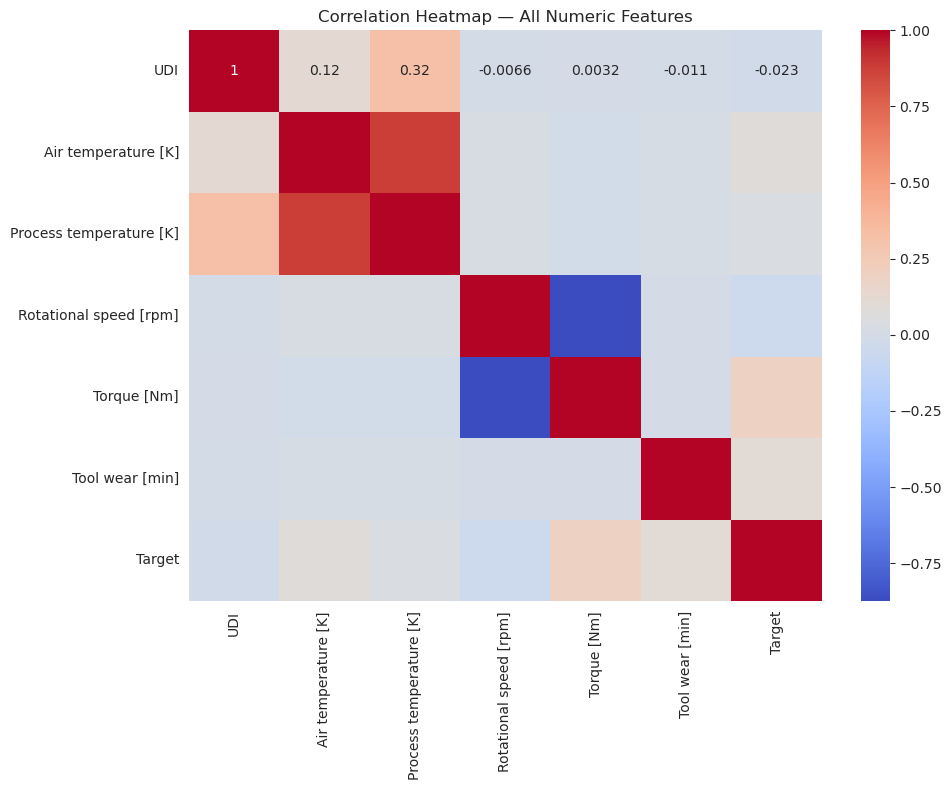

In [11]:
# 3.5  Correlation heatmap of all numeric features
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap — All Numeric Features')
plt.tight_layout()
plt.show()

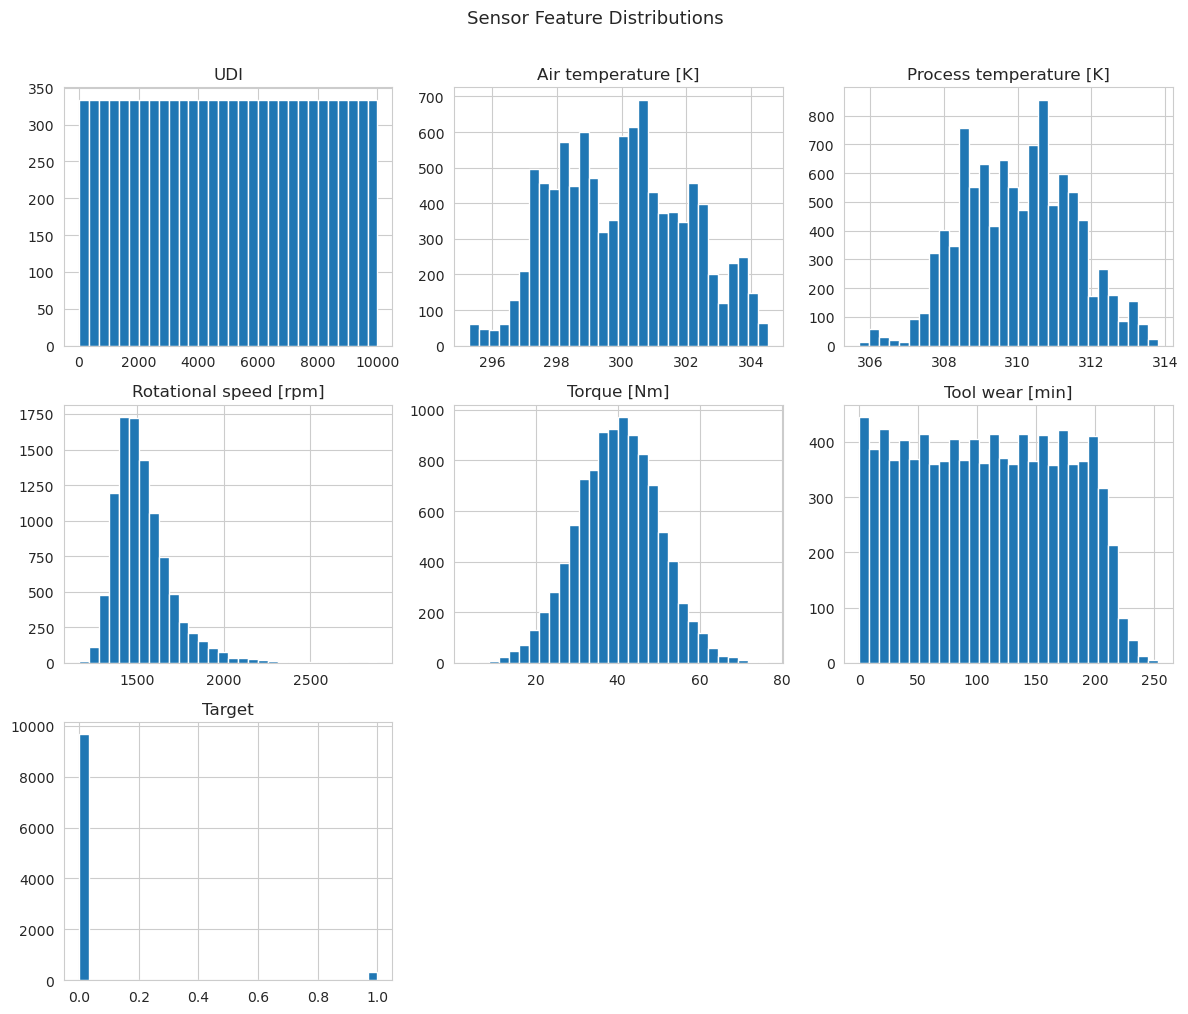

In [12]:
# 3.6  Feature histograms — distribution of each sensor reading
df.hist(figsize=(12, 10), bins=30)
plt.suptitle('Sensor Feature Distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
4. Data Cleaning & Preprocessing
Steps:

Drop ID columns (UDI, Product ID) — row identifiers, carry no predictive signal
Encode Type (L / M / H → 0 / 1 / 2) — ML models require numeric input
Encode Failure Type into 6 numeric classes (0–5) — our target variable
Drop Failure Type and Target — text column replaced by encoded version; binary Target is redundant once we have the multi-class label

In [13]:
# 4.1  Drop non-predictive ID columns
data = df.drop(columns=['UDI', 'Product ID'])
data.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L,298.2,308.7,1408,40.0,9,0,No Failure


In [14]:
# 4.2  Label-encode categorical columns
le_type   = LabelEncoder()
le_target = LabelEncoder()

data['Type'] = le_type.fit_transform(data['Type'])
data['Failure Type Encoded'] = le_target.fit_transform(data['Failure Type'])

print('Failure Type encoding map:')
print(dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

data.head()

Failure Type encoding map:
{'Heat Dissipation Failure': 0, 'No Failure': 1, 'Overstrain Failure': 2, 'Power Failure': 3, 'Random Failures': 4, 'Tool Wear Failure': 5}


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Failure Type Encoded
0,2,298.1,308.6,1551,42.8,0,0,No Failure,1
1,1,298.2,308.7,1408,46.3,3,0,No Failure,1
2,1,298.1,308.5,1498,49.4,5,0,No Failure,1
3,1,298.2,308.6,1433,39.5,7,0,No Failure,1
4,1,298.2,308.7,1408,40.0,9,0,No Failure,1


In [15]:
# 4.3  Drop original text target and redundant binary Target column
data = data.drop(columns=['Failure Type', 'Target'])
print(f'Final feature set: {list(data.columns)}')
data.head()

Final feature set: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Failure Type Encoded']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type Encoded
0,2,298.1,308.6,1551,42.8,0,1
1,1,298.2,308.7,1408,46.3,3,1
2,1,298.1,308.5,1498,49.4,5,1
3,1,298.2,308.6,1433,39.5,7,1
4,1,298.2,308.7,1408,40.0,9,1


In [ ]:
5. Train-Test Split
80 / 20 split — 8,000 training records, 2,000 test records
stratify=y — preserves the proportion of each rare failure class in both sets
(critical here: Random Failures = only 18 total rows, Tool Wear = 45)
random_state=42 — ensures fully reproducible results

In [16]:
X = data.drop(columns=['Failure Type Encoded'])
y = data['Failure Type Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train shape: {X_train.shape}   Test shape: {X_test.shape}')
print(f'\nTraining class counts:')
print(y_train.value_counts())

Train shape: (8000, 6)   Test shape: (2000, 6)

Training class counts:
Failure Type Encoded
1    7722
0      90
3      76
2      62
5      36
4      14
Name: count, dtype: int64


In [ ]:
6. Baseline Model — Random Forest Classifier
Why Random Forest?
Handles non-linear sensor relationships, is robust to outliers, provides built-in feature importance scores, and works well on tabular industrial data without heavy preprocessing.

Why class_weight='balanced'?
Since 96.5% of records are "No Failure", without this setting the model could achieve ~96.5% accuracy by simply predicting "No Failure" every time. The balanced weight forces the model to proportionally penalise errors on rare failure classes.

In [18]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',   # compensates for the 96.5% / 3.5% imbalance
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
7. Baseline Evaluation
Evaluated on the held-out 2,000 test records — never seen during training.
Focus on recall (not just accuracy): missing a real failure is far costlier than a false alarm.

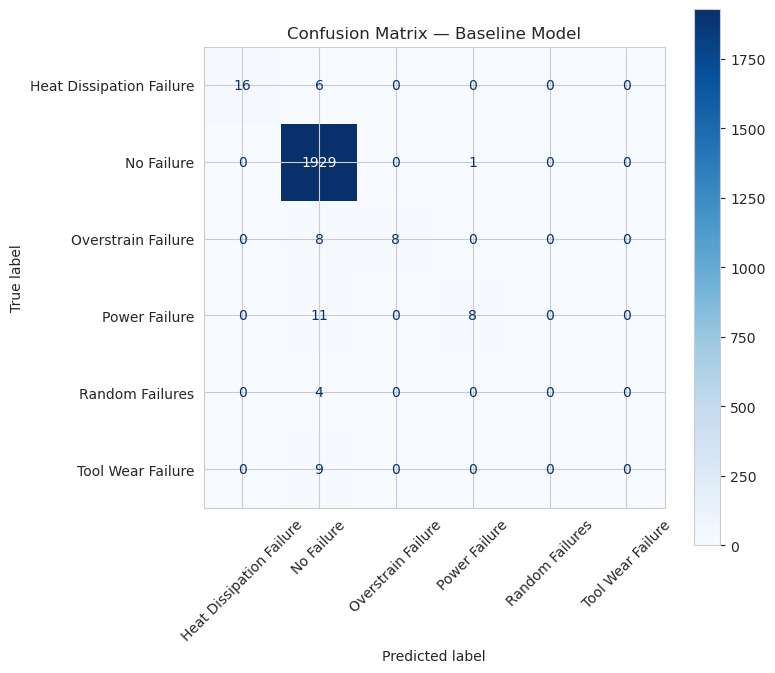

In [20]:
# 7.2  Confusion matrix — baseline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix — Baseline Model')
plt.tight_layout()
plt.show()

In [ ]:
8. Feature Importance
Which sensor readings does the model rely on most?
This tells us why machines fail — directly interpretable in engineering terms.




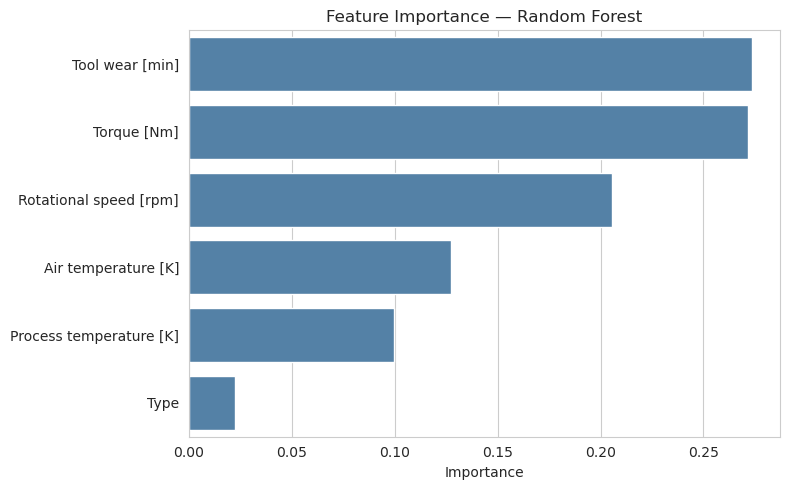


Feature importance values:
Tool wear [min]            0.273488
Torque [Nm]                0.271438
Rotational speed [rpm]     0.205544
Air temperature [K]        0.127606
Process temperature [K]    0.099564
Type                       0.022360
dtype: float64


In [21]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nFeature importance values:')
print(importances)

In [ ]:
9. SMOTE Rebalancing
Problem identified in Section 7: The baseline model achieved 0% recall on Random Failures (14 training examples) and Tool Wear Failure (36 examples) — simply too few real examples to learn a pattern.

Solution — SMOTE (Synthetic Minority Oversampling Technique):
Generates synthetic examples of minority classes by interpolating between real ones, bringing every class up to the same count as the majority class.

⚠️ SMOTE is applied only to the training set — the test set is left untouched so evaluation remains fair and unbiased.
k_neighbors=3 (instead of default 5) is used because some classes have very few original examples — a lower neighbour count avoids errors on such small classes.



In [22]:
!pip install imbalanced-learn --quiet

In [23]:
from imblearn.over_sampling import SMOTE

print('Before SMOTE — training class counts:')
print(y_train.value_counts())

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE — training class counts:')
print(y_train_smote.value_counts())

Before SMOTE — training class counts:
Failure Type Encoded
1    7722
0      90
3      76
2      62
5      36
4      14
Name: count, dtype: int64

After SMOTE — training class counts:
Failure Type Encoded
1    7722
5    7722
4    7722
3    7722
0    7722
2    7722
Name: count, dtype: int64


In [ ]:
10. SMOTE Model Training & Evaluation
We retrain a fresh Random Forest on the SMOTE-balanced training data.
Note: class_weight is not needed here — SMOTE already equalised the class counts.

In [24]:
# 10.1  Train on SMOTE-balanced data
model_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
model_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=200, random_state=42)

In [25]:
# 10.2  Evaluate on the same held-out test set (fair comparison with baseline)
y_pred_smote = model_smote.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred_smote)}')
print()
print(classification_report(y_test, y_pred_smote, target_names=le_target.classes_))

Accuracy: 0.972

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.75      0.95      0.84        22
              No Failure       0.99      0.98      0.99      1930
      Overstrain Failure       0.78      0.88      0.82        16
           Power Failure       0.79      0.79      0.79        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.97      2000
               macro avg       0.55      0.60      0.57      2000
            weighted avg       0.98      0.97      0.97      2000



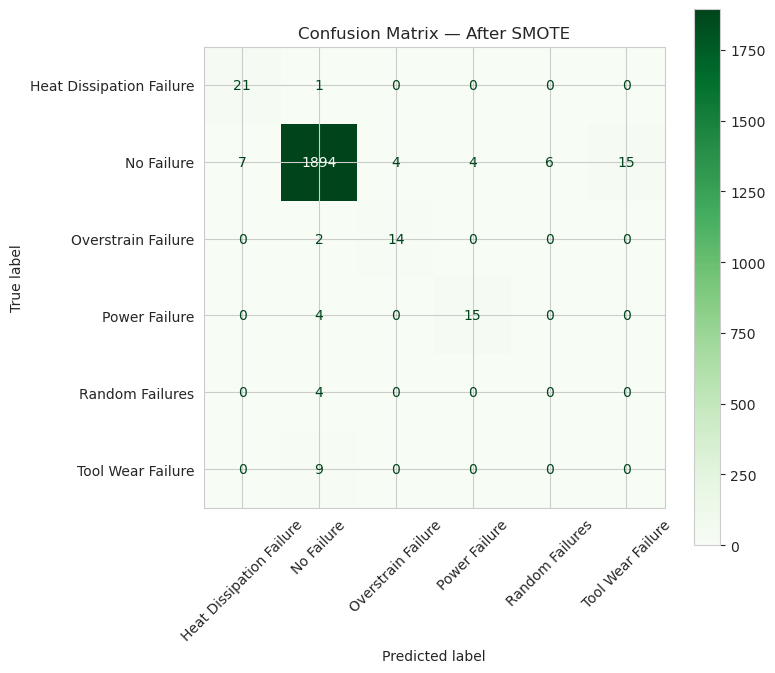

In [26]:
# 10.3  Confusion matrix — after SMOTE
cm_smote = confusion_matrix(y_test, y_pred_smote)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=le_target.classes_)
disp.plot(ax=ax, xticks_rotation=45, cmap='Greens')
plt.title('Confusion Matrix — After SMOTE')
plt.tight_layout()
plt.show()

In [ ]:
11. Cross Validation
5-fold cross validation on the SMOTE model using the full original dataset — gives a more robust estimate of generalisation performance than a single train/test split.

In [27]:
scores = cross_val_score(model_smote, X, y, cv=5)
print('Cross-validation scores (5-fold):')
print(scores)
print(f'\nMean CV accuracy: {scores.mean():.4f}  (±{scores.std():.4f})')

Cross-validation scores (5-fold):
[0.9705 0.9795 0.552  0.977  0.977 ]

Mean CV accuracy: 0.8912  (±0.1696)


In [ ]:
12. Hyperparameter Tuning — GridSearchCV
Searches over a grid of n_estimators and max_depth values to find the combination that maximises cross-validated accuracy on the SMOTE-balanced training data.

In [28]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_smote, y_train_smote)

print(f'\nBest parameters: {grid.best_params_}')
print(f'Best CV score:   {grid.best_score_:.4f}')

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best parameters: {'max_depth': None, 'n_estimators': 200}
Best CV score:   0.9948


In [ ]:
13. Save Best Model
Serialises the best estimator found by GridSearchCV to disk using joblib — so it can be loaded later for inference without retraining.

In [29]:
best_model = grid.best_estimator_
joblib.dump(best_model, 'predictive_maintenance_best_model.pkl')
print('Model saved to: predictive_maintenance_best_model.pkl')
print(f'Best model parameters: {best_model.get_params()}')

Model saved to: predictive_maintenance_best_model.pkl
Best model parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [ ]:
14. Sample Prediction
Demonstrates how to use the saved model to predict the failure type for a new, unseen sensor reading.

In [30]:
# Take a single sample from the test set
sample = X_test.iloc[[0]]
actual = le_target.inverse_transform([y_test.iloc[0]])[0]
predicted = le_target.inverse_transform(best_model.predict(sample))[0]

print('Sample sensor readings:')
print(sample.to_string())
print(f'\nActual failure type:    {actual}')
print(f'Predicted failure type: {predicted}')

Sample sensor readings:
      Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]
3811     2                302.1                    310.7                    1608         30.3               81

Actual failure type:    No Failure
Predicted failure type: No Failure


In [ ]:
15. Conclusion

Key Results
Model	Accuracy	Heat Dissip. Recall	Overstrain Recall	Power Failure Recall
Baseline (class_weight=balanced)	98.05%	0.73	0.50	0.42
After SMOTE	97.20%	0.95	0.88	0.79
Top Feature Importances
Rank	Feature	Importance
1	Tool wear [min]	0.273
2	Torque [Nm]	0.271
3	Rotational speed [rpm]	0.206

Key Findings
Tool wear and torque dominate — together accounting for ~54% of the model's decision weight, consistent with mechanical engineering understanding of machine stress.

SMOTE meaningfully improved minority-class recall — Heat Dissipation (+22pts), Overstrain (+38pts), Power Failure (+37pts) — confirming the value of rebalancing on a heavily skewed industrial dataset.

SMOTE cannot substitute for real data — Random Failures (14 training examples) and Tool Wear Failure (36 examples) remained at 0% recall even after oversampling. SMOTE interpolates between existing points; it cannot create signal that was never captured by the sensors in the first place.

All misclassifications defaulted to 'No Failure' — the model never confused one failure type with another; this is the signature of the majority-class dominance problem.

Future Scope
    
Collect more real sensor data for Random Failures and Tool Wear Failure classes
Compare XGBoost and Gradient Boosting against the Random Forest baseline
Deploy via IBM watsonx.ai Runtime as a live REST API connected to real-time IoT sensor streams
Build a monitoring dashboard to show live machine health and predicted failure risk
Built on IBM Cloud Lite (watsonx.ai Studio) — no paid infrastructure required.
    
AICTE 2026 · IBM SkillsBuild for University Engagements · Problem Statement No. 39

In [ ]:
THANK YOU.